# **Análisis de Simulaciones**

In [1]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import glob 


## Isotermas de presión

In [8]:
resultados = '/run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados'
isotermas = resultados + '/Isotermas'
ronda4 = isotermas + '/Ronda_4'

print(ronda4)

temperaturas = [0.70, 0.80, 1.20]
densidades1 = [0.001, 0.0015, 0.002, 0.002, 0.003, 0.01, 0.025, 0.026, 0.028, 0.03, 0.035, 0.038, 0.04, 0.045, 0.05, 0.075, 0.1]
densidades2 = [0.0020, 0.0030, 0.0040, 0.0050, 0.0060, 0.0070, 0.0080, 0.0090, 0.0100, 0.0120, 0.0170, 0.0200, 0.0300, 0.0350, 0.0400, 0.0450, 0.0460, 0.0470, 0.0480, 0.0490, 0.0500, 0.0550, 0.0600, 0.0700, 0.0800, 0.0900, 0.1000]
densidades3 = [0.0010, 0.0050, 0.0100, 0.0500, 0.1000, 0.1500, 0.1600, 0.1700,0.1800, 0.1900, 0.2047, 0.2100, 0.2200, 0.2300, 0.2400, 0.2500,0.3000, 0.4000, 0.5000]

mapa_simulaciones = {
    0.70: sorted(densidades1),
    0.80: sorted(densidades2),
    1.20: sorted(densidades3)
}

/run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Isotermas/Ronda_4


❌ Archivo no encontrado para: T=0.80, Rho=0.0030
Patrón que glob intentó buscar: /run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Isotermas/Ronda_4/Temp=0.80/Rho=0.0030/*.csv
❌ Archivo no encontrado para: T=0.80, Rho=0.0040
Patrón que glob intentó buscar: /run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Isotermas/Ronda_4/Temp=0.80/Rho=0.0040/*.csv
❌ Archivo no encontrado para: T=0.80, Rho=0.0060
Patrón que glob intentó buscar: /run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Isotermas/Ronda_4/Temp=0.80/Rho=0.0060/*.csv
❌ Archivo no encontrado para: T=0.80, Rho=0.0070
Patrón que glob intentó buscar: /run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Isotermas/Ronda_4/Temp=0.80/Rho=0.0070/*.csv
❌ Archivo no encontrado para: T=0.80, Rho=0.0090
Patrón que glob intentó buscar: /run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Isotermas/Ronda_4/Temp=0.80/Rho=0.0090/*.csv


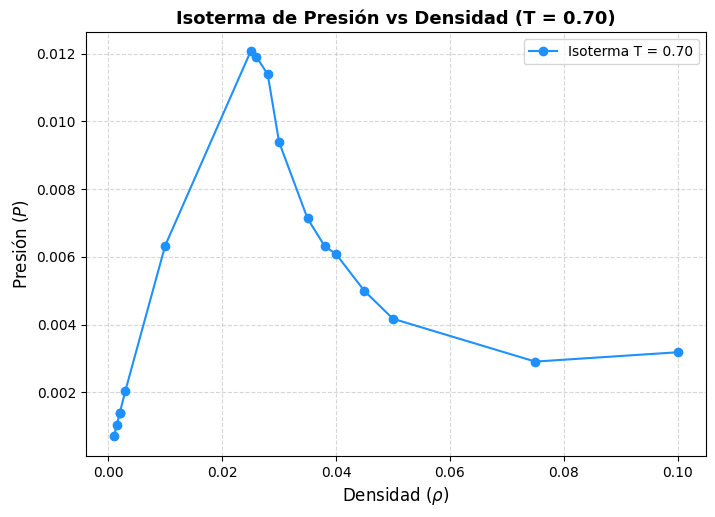

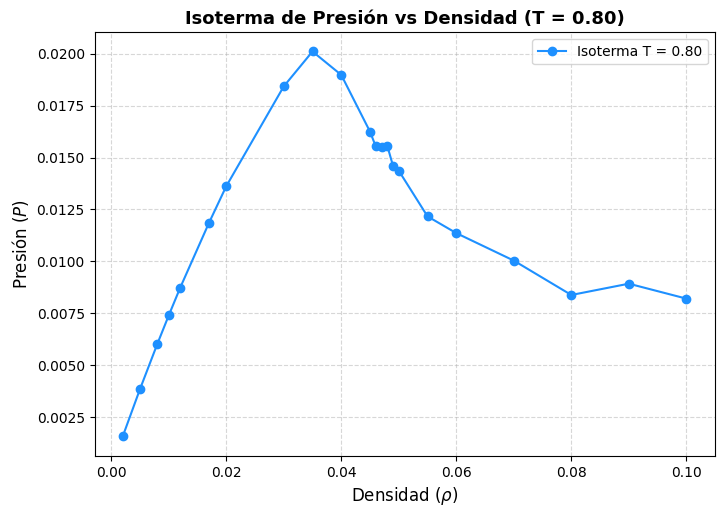

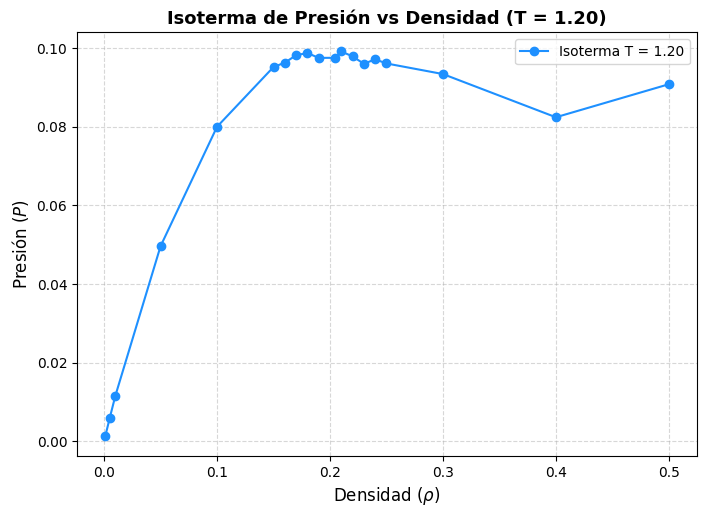

In [9]:
# 3. Iterar sobre cada Isoterma
for T, lista_rhos in mapa_simulaciones.items():
    
    # MODIFICACIÓN: Crear una figura nueva para CADA temperatura
    plt.figure(figsize=(8, 5.5))
    
    rhos_grafica = []
    presiones_promedio = []
    carpeta_T = f'Temp={T:.2f}'
    
    for rho in lista_rhos:
        carpeta_rho = f'{carpeta_T}/Rho={rho:.4f}'
        patron_busqueda = f'{ronda4}/{carpeta_rho}/*.csv'

        ruta_archivo = None 
        archivos_encontrados = glob.glob(patron_busqueda)

        if archivos_encontrados:
            ruta_archivo = archivos_encontrados[0]

            try:
                df = pd.read_csv(ruta_archivo, sep=r'\s+')
                presion_serie = df['md.compute.ThermodynamicQuantities.pressure']
                p_promedio = presion_serie.mean()
                
                rhos_grafica.append(rho)
                presiones_promedio.append(p_promedio)
                
            except Exception as e:
                print(f"Error al procesar el archivo en T={T}, rho={rho}: {e}")
        else:
            print(f"❌ Archivo no encontrado para: T={T:.2f}, Rho={rho:.4f}")
            print(f"Patrón que glob intentó buscar: {patron_busqueda}")
            
    # MODIFICACIÓN: Graficar y configurar de manera individual por temperatura
    if rhos_grafica:
        # Usamos colores diferentes o dejamos que Matplotlib asigne por defecto
        plt.plot(rhos_grafica, presiones_promedio, marker='o', linestyle='-', color='dodgerblue', label=f'Isoterma T = {T:.2f}')
        
        # Configuración estética de la gráfica actual
        plt.xlabel('Densidad ($\\rho$)', fontsize=12)
        plt.ylabel('Presión ($P$)', fontsize=12)
        plt.title(f'Isoterma de Presión vs Densidad (T = {T:.2f})', fontsize=13, fontweight='bold')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(fontsize=10)

        # plt.savefig(f'{ronda4}/isoterma_T_{T:.2f}.png', dpi=300)
        # print(f"✅ Gráfica guardada para T={T:.2f} en: {ronda4}/isoterma_T_{T:.2f}.png")
        # plt.show()

La capacidad calorifica es: 5359.236039370308
La capacidad calorifica es: 5975.371654135595
La capacidad calorifica es: 5962.118155038347
La capacidad calorifica es: 5962.118155038347
La capacidad calorifica es: 6298.221154660076
La capacidad calorifica es: 6391.098960076478
La capacidad calorifica es: 2588573.752288683
La capacidad calorifica es: 5180993.496652733
La capacidad calorifica es: 11578660.311151745
La capacidad calorifica es: 30183701.55886135
La capacidad calorifica es: 18229461.107557207
La capacidad calorifica es: 12941802.829880524
La capacidad calorifica es: 9007086.572967613
La capacidad calorifica es: 3540821.495398289
La capacidad calorifica es: 929905.278648196
La capacidad calorifica es: 52750.20893578657
La capacidad calorifica es: 387293.29763504374
La capacidad calorifica es: 33366.73156996499
La capacidad calorifica es: 54165.55637839627
La capacidad calorifica es: 24703.912420758414
La capacidad calorifica es: 23285.937847433517
La capacidad calorifica es: 1

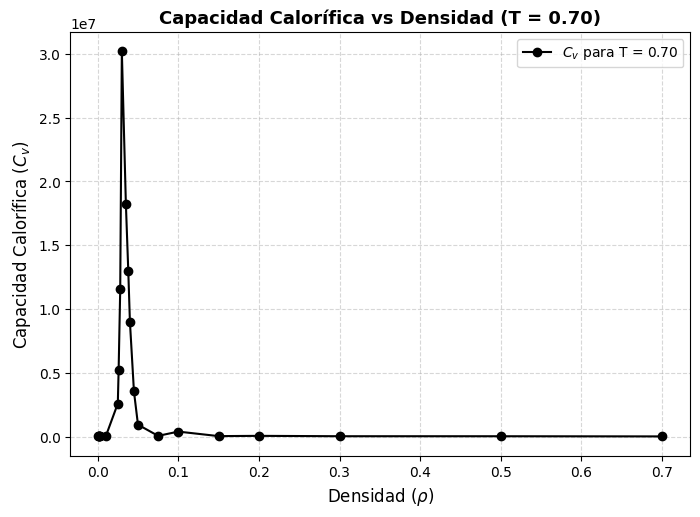

La capacidad calorifica es: 5695.7629415206675
❌ Archivo no encontrado para: T=0.80, Rho=0.0030
❌ Archivo no encontrado para: T=0.80, Rho=0.0040
La capacidad calorifica es: 5868.273208398197
❌ Archivo no encontrado para: T=0.80, Rho=0.0060
❌ Archivo no encontrado para: T=0.80, Rho=0.0070
La capacidad calorifica es: 5795.753336896936
❌ Archivo no encontrado para: T=0.80, Rho=0.0090
La capacidad calorifica es: 6455.775312184349
La capacidad calorifica es: 6155.347967159728
La capacidad calorifica es: 6684.651675519412
La capacidad calorifica es: 7134.76141256314
La capacidad calorifica es: 7589.299947774629
La capacidad calorifica es: 105254.64313249686
La capacidad calorifica es: 5568753.409784264
La capacidad calorifica es: 16214600.125449033
La capacidad calorifica es: 11522707.020439943
La capacidad calorifica es: 11536614.739398276
La capacidad calorifica es: 14726684.142658839
La capacidad calorifica es: 11910064.895185271
La capacidad calorifica es: 13085613.061105978
La capacidad

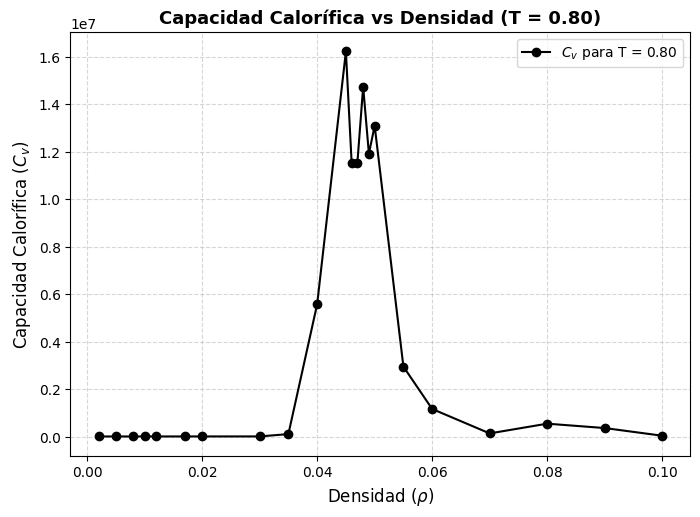

La capacidad calorifica es: 5696.642023390937
La capacidad calorifica es: 5756.100466378441
La capacidad calorifica es: 5620.971324827712
La capacidad calorifica es: 7052.444805583624
La capacidad calorifica es: 7780.773252497188
La capacidad calorifica es: 10691.108512142255
La capacidad calorifica es: 12724.769204236798
La capacidad calorifica es: 15652.713336588116
La capacidad calorifica es: 14676.429810774405
La capacidad calorifica es: 22260.865352490175
La capacidad calorifica es: 32509.256165621508
La capacidad calorifica es: 30683.97476220543
La capacidad calorifica es: 30123.451864274713
La capacidad calorifica es: 52261.0166689885
La capacidad calorifica es: 54856.13498088522
La capacidad calorifica es: 39278.85583245648
La capacidad calorifica es: 30090.3027244388
La capacidad calorifica es: 28116.822052861993
La capacidad calorifica es: 8676.351412535081
✅ Gráfica de Cv guardada para T=1.20 en: /run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Isotermas/Ronda_

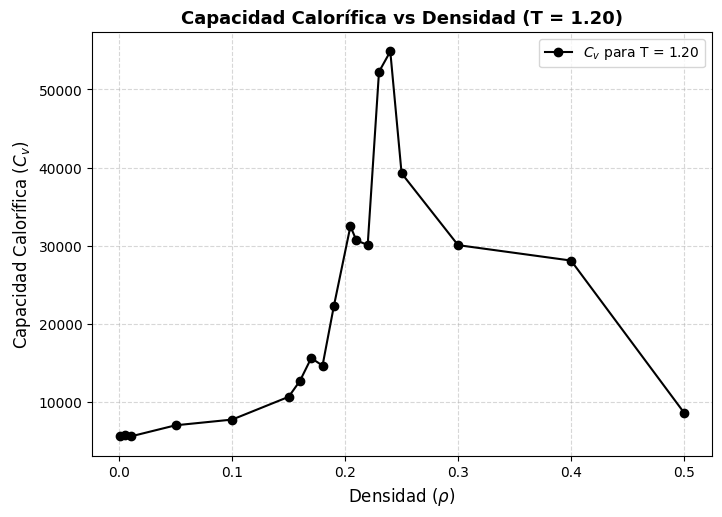

In [4]:
from funciones import calcular_cv_hoomd

for T, lista_rhos in mapa_simulaciones.items():
    
    # Inicializar lienzo para la gráfica de Cv de la temperatura actual
    plt.figure(figsize=(8, 5.5))
    
    rhos_grafica = []
    cv_resultados = []  # Lista para almacenar los valores de Cv calculados
    carpeta_T = f'Temp={T:.2f}'
    
    for rho in lista_rhos:
        carpeta_rho = f'{carpeta_T}/Rho={rho:.4f}'
        patron_busqueda = f'{ronda4}/{carpeta_rho}/*.csv'

        ruta_archivo = None 
        archivos_encontrados = glob.glob(patron_busqueda)

        if archivos_encontrados:
            ruta_archivo = archivos_encontrados[0]

            try:
                # Leer el archivo de la simulación
                df = pd.read_csv(ruta_archivo, sep=r'\s+')

                # Calcular Cv usando tu función importada
                cv_valor = calcular_cv_hoomd(df=df, T=T)
                
                # Guardar los datos emparejados si el cálculo fue exitoso
                rhos_grafica.append(rho)
                cv_resultados.append(cv_valor)
                
            except Exception as e:
                print(f"❌ Error al calcular Cv en T={T:.2f}, rho={rho:.4f}: {e}")
        else:
            print(f"❌ Archivo no encontrado para: T={T:.2f}, Rho={rho:.4f}")
            
    # Graficar la Capacidad Calorífica una vez que termine de recorrer las densidades de esta T
    if rhos_grafica:
        # Usamos un color diferente (crimson/rojo) para distinguir esta propiedad de la presión
        plt.plot(rhos_grafica, cv_resultados, marker='o', linestyle='-', color='black', label=f'$C_v$ para T = {T:.2f}')
        
        # Configuración estética de la gráfica de transiciones de fase
        plt.xlabel('Densidad ($\\rho$)', fontsize=12)
        plt.ylabel('Capacidad Calorífica ($C_v$)', fontsize=12)
        plt.title(f'Capacidad Calorífica vs Densidad (T = {T:.2f})', fontsize=13, fontweight='bold')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(fontsize=10)
        
        # Guardar la gráfica antes de mostrarla para evitar el lienzo en blanco
        ruta_guardado = f'{ronda4}/capacidad_calorifica_T_{T:.2f}.png'
        plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfica de Cv guardada para T={T:.2f} en: {ruta_guardado}")
        
        # Mostrar en el Notebook
        plt.show()
    


================ Generando Gráfica Solapada de Capacidad Calorífica ================

-> Procesando T = 0.70
La capacidad calorifica es: 5359.236039370308
La capacidad calorifica es: 5975.371654135595
La capacidad calorifica es: 5962.118155038347
La capacidad calorifica es: 5962.118155038347
La capacidad calorifica es: 6298.221154660076
La capacidad calorifica es: 6391.098960076478
La capacidad calorifica es: 2588573.752288683
La capacidad calorifica es: 5180993.496652733
La capacidad calorifica es: 11578660.311151745
La capacidad calorifica es: 30183701.55886135
La capacidad calorifica es: 18229461.107557207
La capacidad calorifica es: 12941802.829880524
La capacidad calorifica es: 9007086.572967613
La capacidad calorifica es: 3540821.495398289
La capacidad calorifica es: 929905.278648196
La capacidad calorifica es: 52750.20893578657
La capacidad calorifica es: 387293.29763504374
La capacidad calorifica es: 33366.73156996499
La capacidad calorifica es: 54165.55637839627
La capacidad 

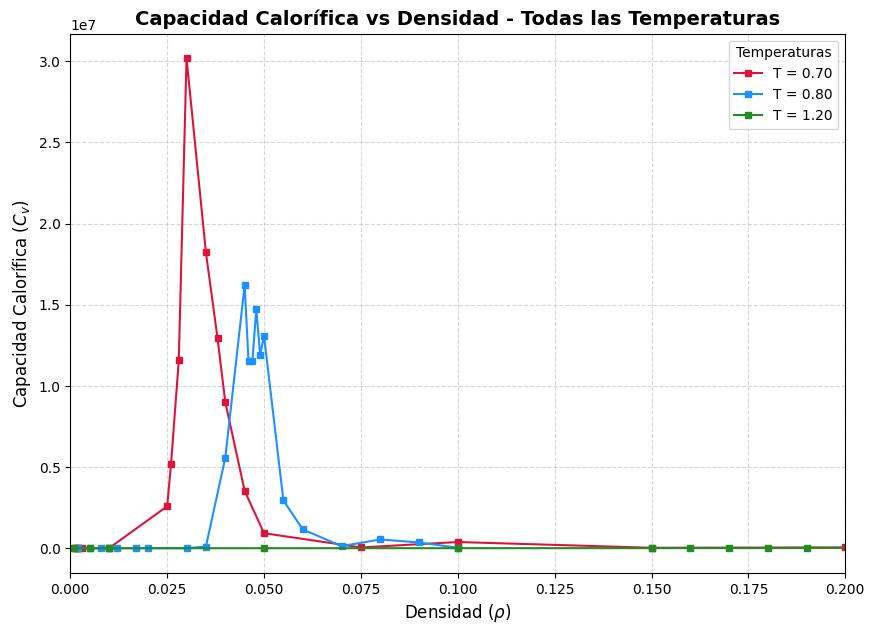

In [5]:
plt.figure(figsize=(10, 7))

# Lista de colores para diferenciar cada temperatura fácilmente
colores = ['crimson', 'dodgerblue', 'forestgreen']
color_index = 0

print("\n================ Generando Gráfica Solapada de Capacidad Calorífica ================")

# Itere sobre cada Isoterma para calcular Cv
for T, lista_rhos in mapa_simulaciones.items():
    
    rhos_grafica = []
    cv_resultados = []  # Lista para almacenar los valores de Cv calculados para esta T
    carpeta_T = f'Temp={T:.2f}'
    
    print(f"\n-> Procesando T = {T:.2f}")
    
    for rho in lista_rhos:
        carpeta_rho = f'{carpeta_T}/Rho={rho:.4f}'
        patron_busqueda = f'{ronda4}/{carpeta_rho}/*.csv'

        archivos_encontrados = glob.glob(patron_busqueda)

        if archivos_encontrados:
            ruta_archivo = archivos_encontrados[0]

            try:
                # Leer el archivo de la simulación
                df = pd.read_csv(ruta_archivo, sep=r'\s+')

                # Calcular Cv usando tu función importada
                # (Si los prints dentro de la función son muy ruidosos, considera comentarlos allí)
                cv_valor = calcular_cv_hoomd(df=df, T=T)
                
                # Guardar los datos emparejados si el cálculo fue exitoso
                rhos_grafica.append(rho)
                cv_resultados.append(cv_valor)
                
            except Exception as e:
                print(f"❌ Error al calcular Cv en T={T:.2f}, rho={rho:.4f}: {e}")
        else:
            # Puedes usar 'pass' para un reporte más limpio o dejar el print para depurar
            # print(f"Archivo no encontrado para: T={T:.2f}, Rho={rho:.4f}")
            pass
            
    # --- DENTRO DEL BUCLE DE T, PERO FUERA DEL BUCLE DE DENSIDAD ---
    # Graficar la línea completa de Cv para la temperatura actual en el lienzo solapado
    if rhos_grafica:
        # Usamos colores dinámicos y estilos para diferenciar
        color_actual = colores[color_index % len(colores)]
        plt.plot(rhos_grafica, cv_resultados, 
                 marker='s', markersize=4, linestyle='-', 
                 color=color_actual, label=f'T = {T:.2f}')
        color_index += 1  # Siguiente color para la próxima temperatura

# --- 3. FINALIZACIÓN Y GUARDADO DE LA GRÁFICA SOLAPADA ---

# Configuración estética final (se aplica una sola vez a todo el gráfico)
plt.xlabel('Densidad ($\\rho$)', fontsize=12)
plt.ylabel('Capacidad Calorífica ($C_v$)', fontsize=12)
plt.title('Capacidad Calorífica vs Densidad - Todas las Temperaturas', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

plt.xlim(0, 0.20)  # Ajusta según el rango de densidades que tengas

# La leyenda es crucial para identificar qué línea es qué temperatura
plt.legend(title="Temperaturas", fontsize=10, loc='upper right')

# Primero guardamos en el disco
ruta_guardado_solapado = f'{ronda4}/capacidad_calorifica_comparativa_solapada.png'
plt.savefig(ruta_guardado_solapado, dpi=300, bbox_inches='tight')
print(f"\n💾 Gráfica comparativa guardada exitosamente en: {ruta_guardado_solapado}")

# Mostramos en el Notebook
plt.show()
plt.close()